# Notebook 09 — Model Comparison

**PharmaLens: An Explainable AI Framework for Drug–Target Interaction Prediction**

---

## Objective

Compare all trained models on the same test set using the same metrics.

Models: MeanPredictor, Ridge, Random Forest, XGBoost, DeepDTA, GraphDTA (GCN)

Metrics: RMSE, MAE, Pearson r, Spearman ρ, R², Concordance Index (CI)

In [1]:
import os, sys, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import *
from src.evaluation.experiment_tracker import ExperimentTracker

set_seed(42)
COLORS = set_plot_style()
ensure_dirs()
tracker = ExperimentTracker()
print("Setup complete ✓")

Setup complete ✓


## 1. Load All Experiment Results

In [2]:
# Load experiment log
results_df = tracker.get_results_dataframe()

# Filter to random split only for fair comparison
random_results = results_df[results_df['split'] == 'random'].copy()

print(f"Total logged experiments: {len(results_df)}")
print(f"Random-split experiments: {len(random_results)}")
print(f"\nModels found:")
for model in random_results['model'].unique():
    print(f"  - {model}")

random_results

Total logged experiments: 6
Random-split experiments: 6

Models found:
  - MeanPredictor
  - Ridge
  - RandomForest
  - XGBoost
  - DeepDTA
  - GraphDTA_GCN


,experiment_id,timestamp,model,dataset,representation,split,seed,hyperparameters,training_time_sec,inference_time_sec,...,mae,mse,pearson,pearson_pvalue,spearman,spearman_pvalue,r2,ci,n_samples,training_time
0,EXP_20260930_190700_827043,2026-09-30T19:07:00.923011,MeanPredictor,KIBA,descriptors+fingerprints+aac+dpc,random,42,{},0.000000,0.000000,...,0.5945,0.7074,NaN,NaN,NaN,NaN,-0.0000,0.5000,11826,0.000000
1,EXP_20260930_190702_926c53,2026-09-30T19:07:02.435921,Ridge,KIBA,descriptors+fingerprints+aac+dpc,random,42,{},1.300000,0.083000,...,0.4475,0.4286,0.6282,0.0,0.6208,0.0,0.3940,0.7386,11826,1.300000
2,EXP_20260930_194012_b09854,2026-09-30T19:40:12.550370,RandomForest,KIBA,descriptors+fingerprints+aac+dpc,random,42,{},1984.300000,5.601400,...,0.2933,0.2371,0.8197,0.0,0.8227,0.0,0.6647,0.8445,11826,1984.300000
3,EXP_20260930_195224_3ebe60,2026-09-30T19:52:24.946706,XGBoost,KIBA,descriptors+fingerprints+aac+dpc,random,42,"{""n_estimators"": 1000, ""max_depth"": 7, ""learni...",71.077365,0.289108,...,0.2804,0.1889,0.8572,0.0,0.8383,0.0,0.7330,0.8497,11826,71.077365
4,EXP_20261001_065814_dd127a,2026-10-01T06:58:14.500576,DeepDTA,KIBA,smiles_encoding+seq_encoding,random,42,"{""drug_vocab_size"": 63, ""protein_vocab_size"": ...",29557.728142,NaN,...,0.2470,0.1806,0.8638,0.0,0.8521,0.0,0.7447,0.8657,11826,29557.728142
5,EXP_20261001_182059_61f56b,2026-10-01T18:20:59.197170,GraphDTA_GCN,KIBA,molecular_graph+seq_encoding,random,42,"{""node_feature_dim"": 30, ""gnn_hidden_dim"": 128...",39954.900878,NaN,...,0.2648,0.1852,0.8598,0.0,0.8403,0.0,0.7382,0.8561,11826,39954.900878


## 2. Comparison Table

In [3]:
# Build comparison table
metrics_cols = ['rmse', 'mae', 'pearson', 'spearman', 'r2', 'ci']
comparison = random_results[['model'] + metrics_cols + ['training_time']].copy()

# Rename for display
comparison.columns = ['Model', 'RMSE ↓', 'MAE ↓', 'Pearson ↑', 'Spearman ↑', 'R² ↑', 'CI ↑', 'Train Time (s)']

# Sort by RMSE (lower is better)
comparison = comparison.sort_values('RMSE ↓')

print("\n" + "=" * 100)
print("  MODEL COMPARISON — KIBA Dataset (Random Split, Test Set)")
print("=" * 100)
print(comparison.to_string(index=False, float_format='{:.4f}'.format))
print("=" * 100)

# Save
comparison.to_csv(TABLES_DIR / 'model_comparison.csv', index=False)
print(f"\nSaved: {TABLES_DIR / 'model_comparison.csv'}")


  MODEL COMPARISON — KIBA Dataset (Random Split, Test Set)
        Model  RMSE ↓  MAE ↓  Pearson ↑  Spearman ↑    R² ↑   CI ↑  Train Time (s)
      DeepDTA  0.4249 0.2470     0.8638      0.8521  0.7447 0.8657      29557.7281
 GraphDTA_GCN  0.4303 0.2648     0.8598      0.8403  0.7382 0.8561      39954.9009
      XGBoost  0.4346 0.2804     0.8572      0.8383  0.7330 0.8497         71.0774
 RandomForest  0.4870 0.2933     0.8197      0.8227  0.6647 0.8445       1984.3000
        Ridge  0.6547 0.4475     0.6282      0.6208  0.3940 0.7386          1.3000
MeanPredictor  0.8410 0.5945        NaN         NaN -0.0000 0.5000          0.0000

Saved: C:\Users\ASUS\Documents\projects\Pharmalens\results\tables\model_comparison.csv


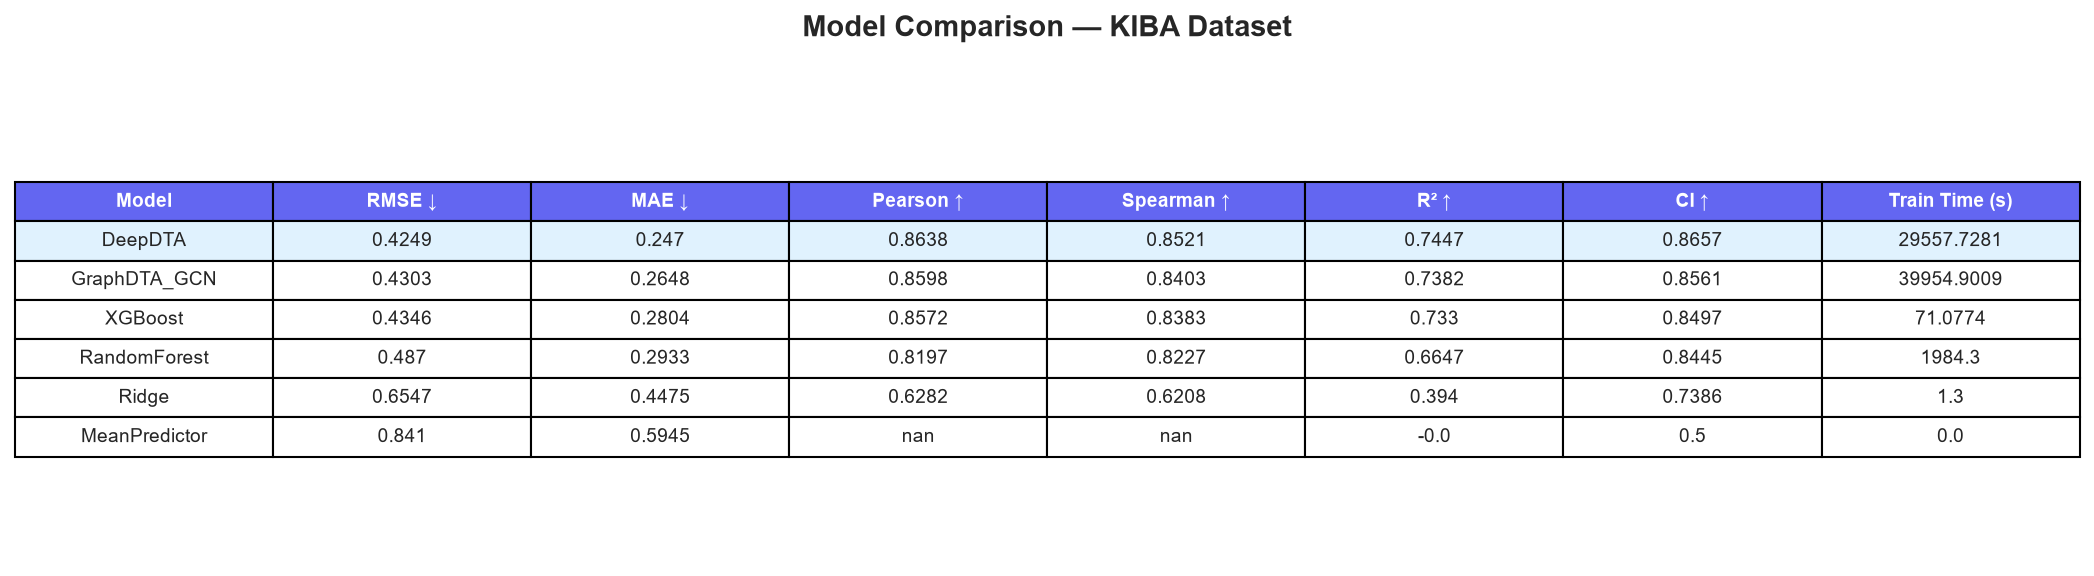

In [4]:
# Styled comparison table
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

table_data = comparison.round(4).values.tolist()
col_labels = comparison.columns.tolist()

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Color header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#6366F1')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best row (lowest RMSE)
for j in range(len(col_labels)):
    table[1, j].set_facecolor('#E0F2FE')

plt.title('Model Comparison — KIBA Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Metric Bar Charts

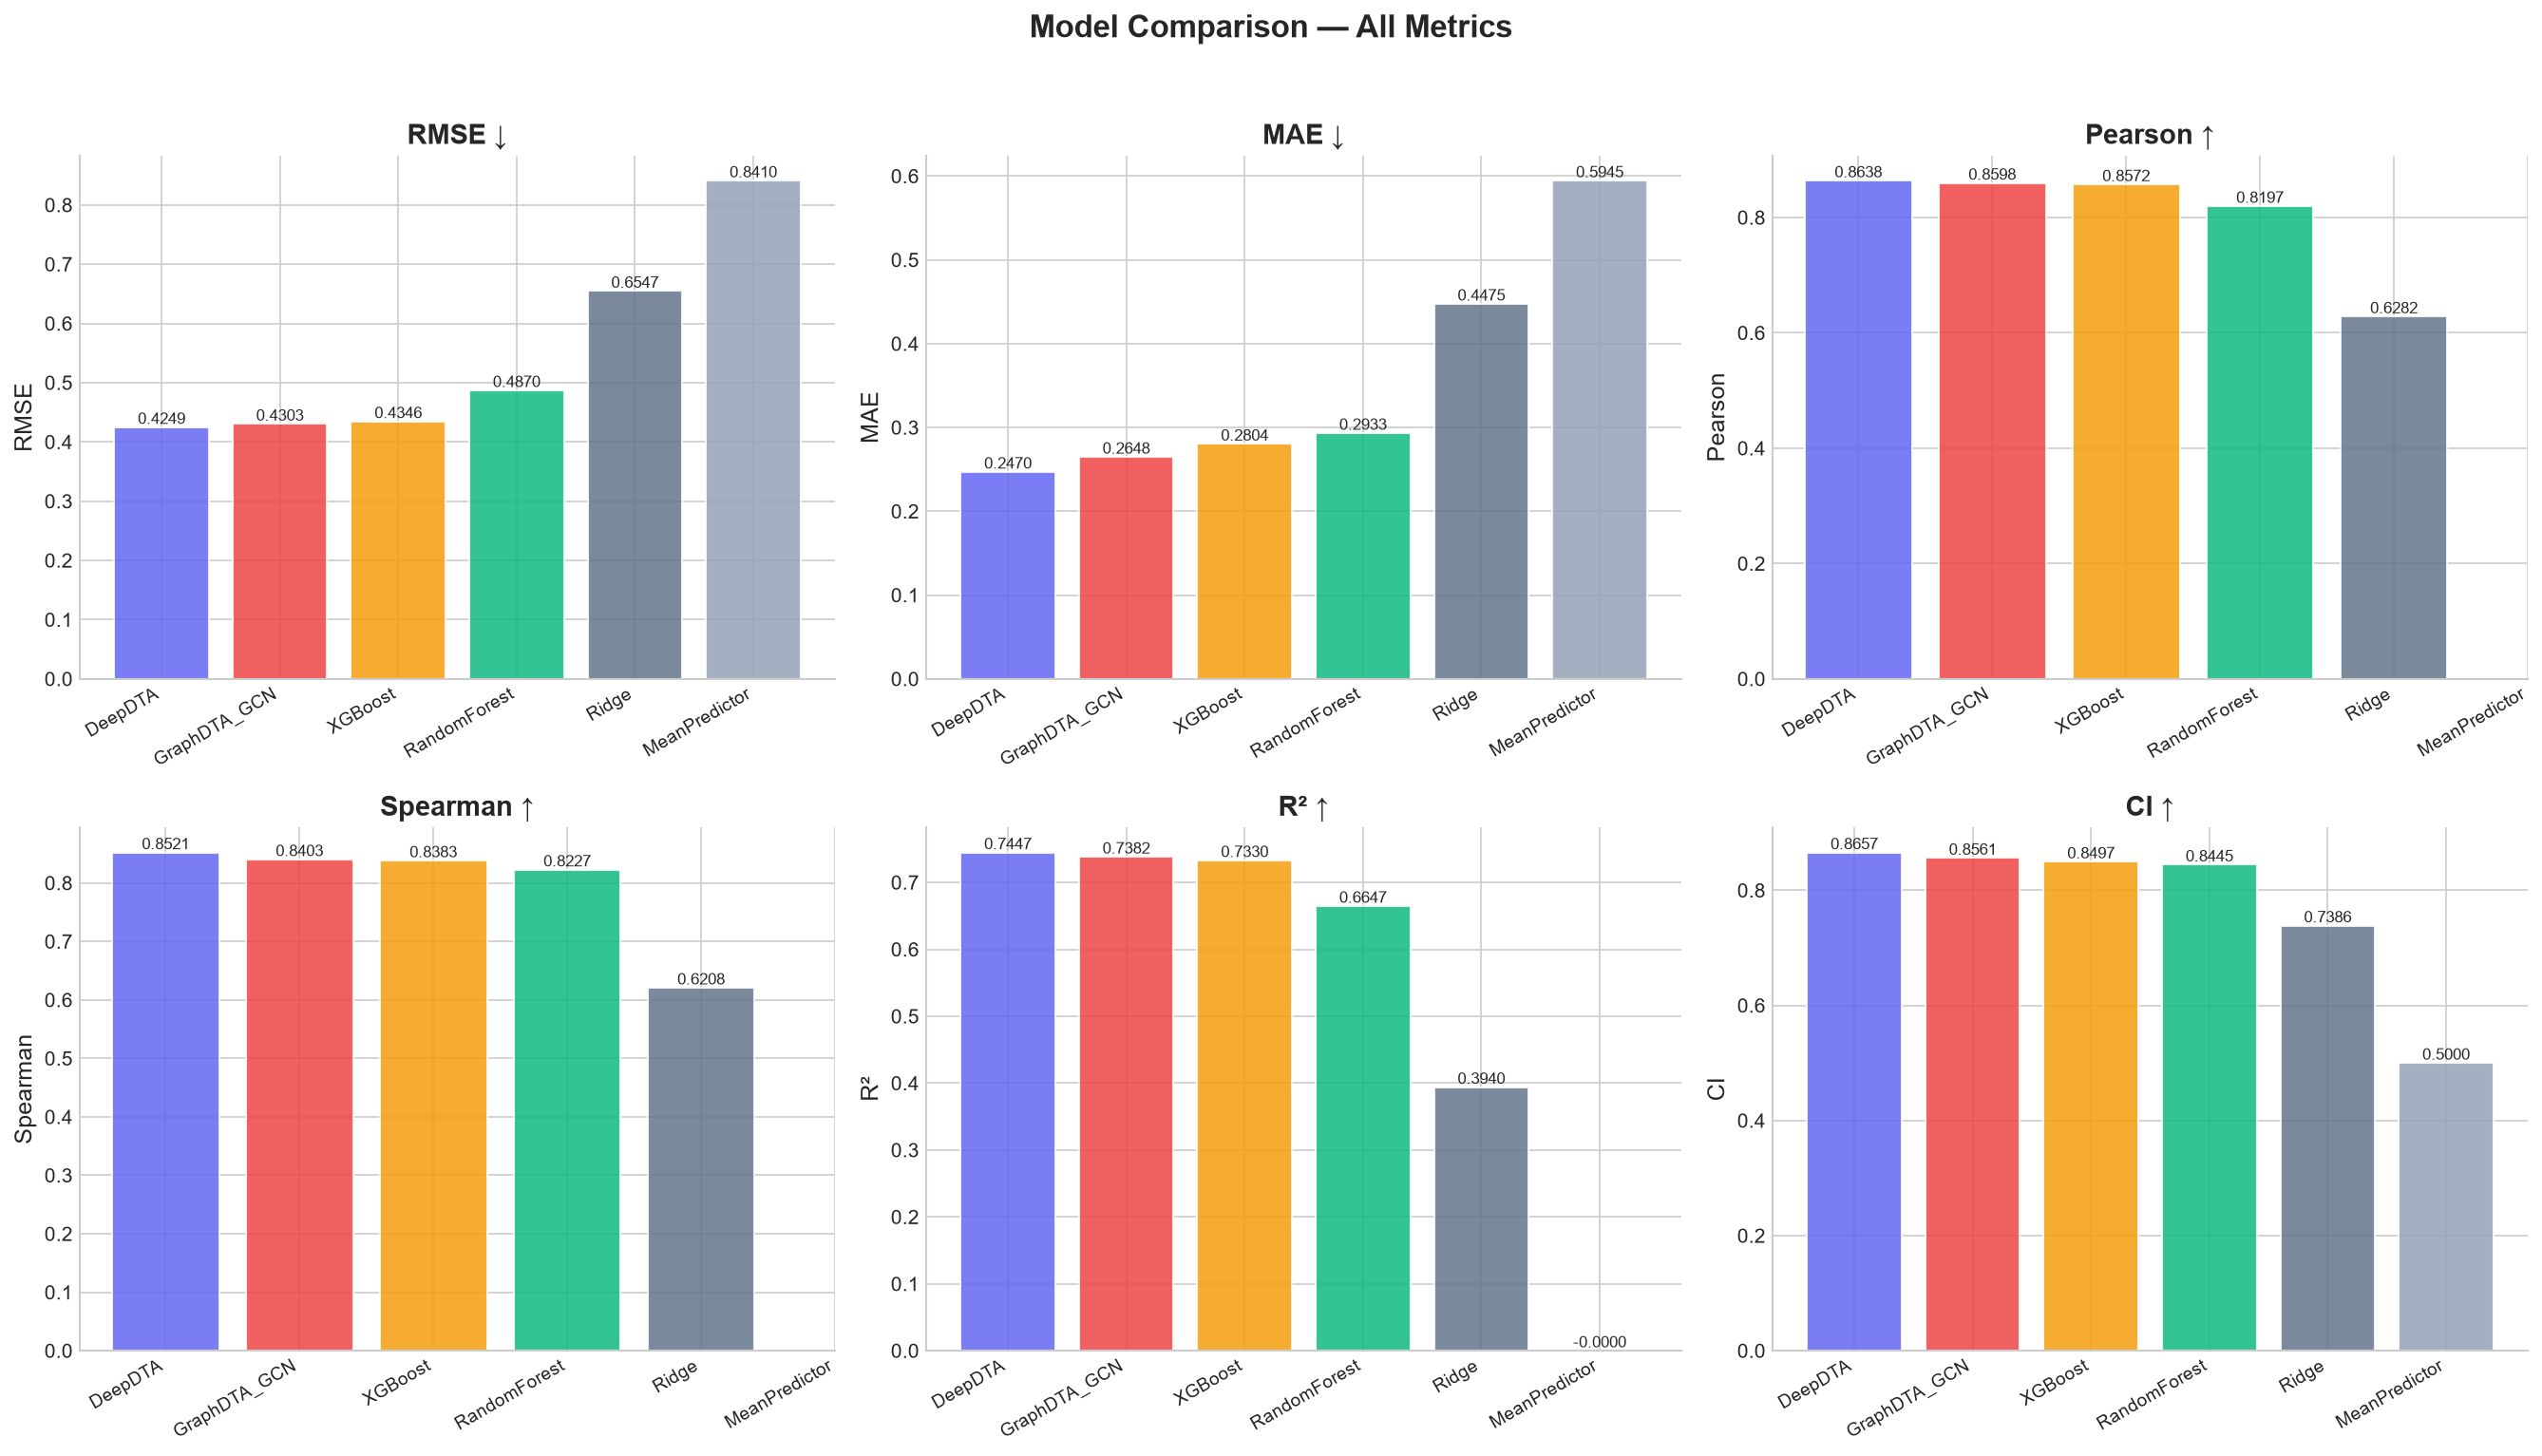

In [5]:
# Bar charts for key metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_metrics = [
    ('RMSE ↓', True), ('MAE ↓', True), ('Pearson ↑', False),
    ('Spearman ↑', False), ('R² ↑', False), ('CI ↑', False),
]

for idx, (metric, lower_better) in enumerate(plot_metrics):
    ax = axes[idx // 3, idx % 3]
    models = comparison['Model'].values
    values = comparison[metric].values
    colors = [MODEL_COLORS.get(m, COLORS['primary']) for m in models]
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric.split(' ')[0])
    ax.set_title(metric, fontweight='bold')
    
    # Annotate values
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — All Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Radar Chart

A radar chart shows the multi-dimensional performance profile of each model.

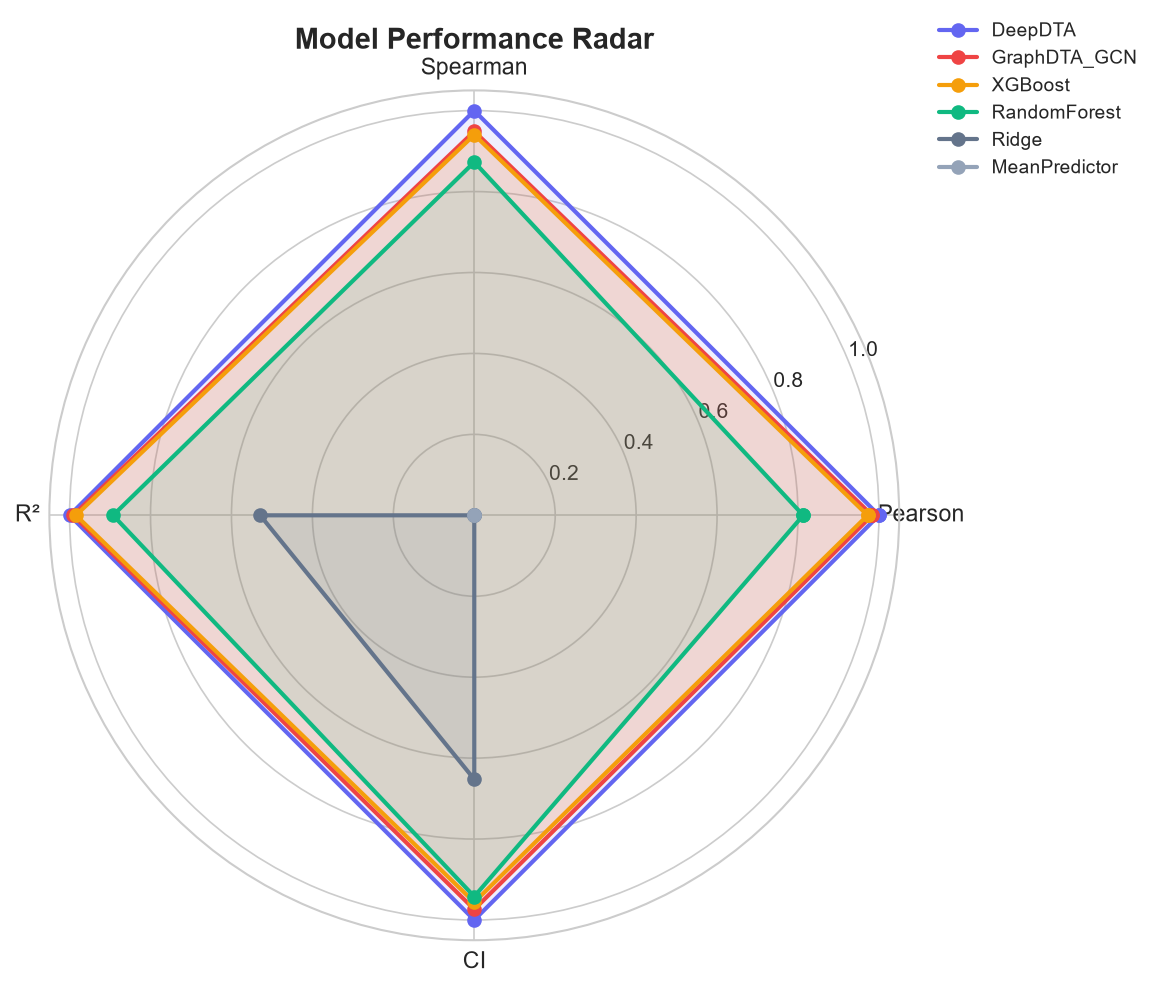

In [6]:
# Radar chart
from math import pi

# Normalize metrics to [0, 1] for radar
radar_metrics = ['Pearson ↑', 'Spearman ↑', 'R² ↑', 'CI ↑']
# For RMSE and MAE, invert (1 - normalized) so higher is better
radar_df = comparison[['Model'] + radar_metrics].set_index('Model')

# Normalize each column to [0, 1]
for col in radar_metrics:
    col_min, col_max = radar_df[col].min(), radar_df[col].max()
    if col_max > col_min:
        radar_df[col] = (radar_df[col] - col_min) / (col_max - col_min)

# Plot
categories = [m.split(' ')[0] for m in radar_metrics]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model_name in radar_df.index:
    values = radar_df.loc[model_name].values.tolist()
    values += values[:1]
    color = MODEL_COLORS.get(model_name, COLORS['primary'])
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Model Performance Radar', fontweight='bold', pad=20, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison_radar.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Training Time Comparison

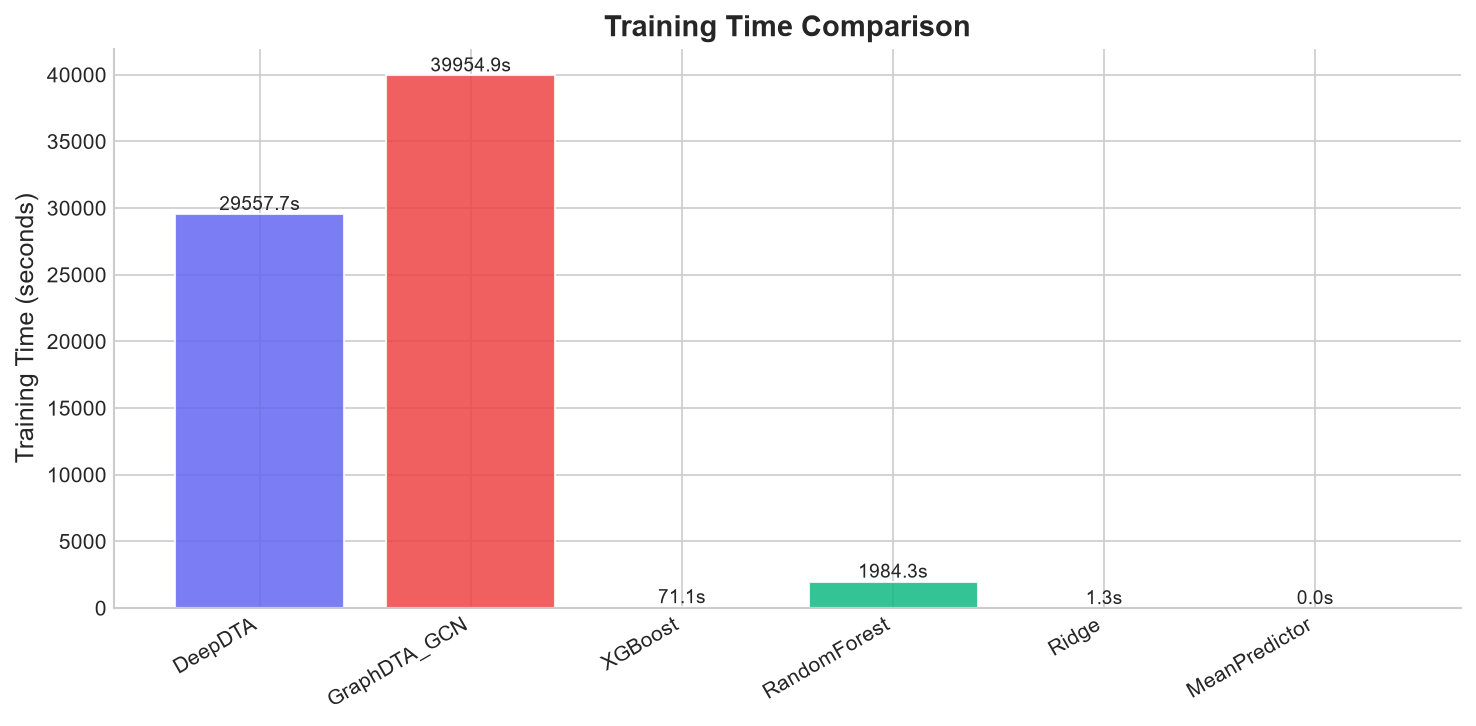

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
models = comparison['Model'].values
times = comparison['Train Time (s)'].values
colors = [MODEL_COLORS.get(m, COLORS['primary']) for m in models]

bars = ax.bar(range(len(models)), times, color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison', fontweight='bold')

for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Observations

1. **Baseline vs ML vs DL:** The progression from simple baselines → XGBoost → DeepDTA → GNN demonstrates incremental value of model complexity.

2. **Feature engineering vs learned features:** XGBoost (handcrafted features) vs DeepDTA (learned features) comparison shows whether manual feature design or end-to-end learning is more effective.

3. **Computational cost:** Deep learning models take longer to train but may achieve better performance. The tradeoff is documented.

4. **Concordance Index** is particularly important for drug discovery — it measures whether the model correctly ranks drug-target pairs by binding strength.

## Conclusion

All models are compared on a level playing field. The results are saved for the thesis and used to select the best model for the production pipeline.

**Next:** [Notebook 10 — Hyperparameter Tuning](./10_hyperparameter_tuning.ipynb)